# T64 — PBDB paleobiogeography workflow

**Cluster I: Paleobiogeography.**

The [Paleobiology Database](https://paleobiodb.org) (PBDB) is a community-curated archive of ~1.8 million fossil occurrences with taxonomic identifications, stratigraphic ages, and present-day coordinates. Reconstructing PBDB occurrences to their paleo-positions is one of the workhorse operations in paleontological biogeography — it's how questions like "were dinosaurs distributed across a single Pangaean supercontinent?" or "did marine invertebrate distributions collapse across the end-Permian?" get quantitative treatment.

Nothing in the suite currently pulls live PBDB records. This notebook fills that gap.

## What this notebook produces

1. **§3 — Query the PBDB API live.** A single HTTPS GET returns fossil occurrences filtered by taxon + time interval as CSV. We drop these straight into pandas.
2. **§4 — Reconstruct to paleo-position.** Every occurrence gets a plate ID via point-in-polygon against Z22 static polygons; then each is reconstructed to a target age using its collection midpoint age (not the target age, which would be biologically wrong).
3. **§5 — Paleo-Earth map by taxonomic group.** Three interleaved queries (dinosaurs, mammals, marine invertebrates) plotted with distinct symbols on the same paleo-Earth. Shows biogeographic contrast at the chosen age.
4. **§6 — Latitudinal-diversity gradient.** Sample-count histogram against paleolatitude, colour-coded by taxonomic group. Reproduces the classic tropical-diversity-peak pattern at appropriate ages.

## Learning objectives

- Query the PBDB API programmatically (URL construction + pandas ingestion).
- Assign plate IDs to a fossil-occurrence table by point-in-polygon.
- Reconstruct each occurrence to its own collection-midpoint age (not a common target age) — the biologically-correct workflow.
- Encode taxonomic group as pyGMT symbol style.
- Build a latitude-binned diversity histogram.

## Prerequisites and runtime

- Live network access to <https://paleobiodb.org/data1.2/>. If offline, the notebook prints an informative error and skips the query.
- Python: `gplately`, `pygplates`, `pygmt`, `pandas`, `numpy`, `matplotlib`, `requests`.
- Runtime: ~15 s per PBDB query (network-bound) + ~10 s reconstruction + ~5 s pyGMT rendering per panel. Typical total ~90 s.


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, io
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import requests
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, pygmt, gplately, pygplates, requests):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME          = "Zahirovic2022"
ANCHOR_PLATE_ID     = 0                       # mantle frame — fine for paleogeography

# Target age for the §5 map + §6 histogram
RECONSTRUCTION_TIME = 100.0                   # Ma; mid-Cretaceous

# PBDB queries: taxon + time-interval + optional filters. Each entry becomes a
# separate API GET. Style pairs the taxon with a pyGMT symbol + colour for §5.
PBDB_QUERIES = {
    "Dinosauria": {
        "params": {"base_name": "Dinosauria",
                   "interval": "Cretaceous",
                   "show": "coords,paleoloc,strat,timebins"},
        "style":  {"symbol": "t0.28c", "fill": "#c0392b"},  # red triangles
    },
    "Mammalia": {
        "params": {"base_name": "Mammalia",
                   "interval": "Cretaceous",
                   "show": "coords,paleoloc,strat,timebins"},
        "style":  {"symbol": "s0.22c", "fill": "#f39c12"},  # orange squares
    },
    "Ammonoidea": {
        "params": {"base_name": "Ammonoidea",
                   "interval": "Cretaceous",
                   "show": "coords,paleoloc,strat,timebins"},
        "style":  {"symbol": "c0.20c", "fill": "#2980b9"},  # blue circles
    },
}

# Downsample large query results before reconstruction (per taxon)
MAX_OCCURRENCES_PER_TAXON = 400

# Latitude-histogram bin width (§6)
LAT_BIN_DEG         = 10
# ============================================================================
print(f"  model:        {MODEL_NAME}")
print(f"  target time:  {RECONSTRUCTION_TIME} Ma")
print(f"  queries:      {list(PBDB_QUERIES.keys())}")


  model:        Zahirovic2022
  target time:  100.0 Ma
  queries:      ['Dinosauria', 'Mammalia', 'Ammonoidea']


## 1. Query the PBDB API

The PBDB REST API returns CSV that pandas can ingest directly. Query documentation: <https://paleobiodb.org/data1.2/occs/list_doc.html>.

Key parameters:
- **base_name** — taxon name (e.g. `Dinosauria`, `Mammalia`, `Ammonoidea`). PBDB expands to all descendants.
- **interval** — geological interval name (`Cretaceous`, `Jurassic`, `Late Cretaceous`, `Cenomanian`, etc.) or `min_ma`/`max_ma` pair.
- **show=coords,paleoloc,strat,timebins** — include present-day coordinates, PBDB's own paleocoordinates (as a sanity check), lithostratigraphic info, and time-bin midpoints.

We wrap the request in a try/except so an offline run prints a message rather than a stack trace.


In [3]:
PBDB_URL = "https://paleobiodb.org/data1.2/occs/list.csv"

def query_pbdb(params, max_rows=None):
    """GET one PBDB query, return DataFrame. Returns empty DataFrame on network fail."""
    try:
        r = requests.get(PBDB_URL, params=params, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
    except Exception as e:
        print(f"  [network] failed to fetch {params.get('base_name', '?')}: {e}")
        return pd.DataFrame()
    if max_rows and len(df) > max_rows:
        df = df.sample(max_rows, random_state=42).sort_index()
    return df

pbdb_dfs = {}
for taxon, cfg in PBDB_QUERIES.items():
    print(f"  Querying PBDB for {taxon}...")
    df = query_pbdb(cfg["params"], max_rows=MAX_OCCURRENCES_PER_TAXON)
    pbdb_dfs[taxon] = df
    if len(df) > 0:
        # Standardise column names — PBDB uses lng/lat/max_ma/min_ma with 'lng' spelling
        print(f"    {len(df):>4d} occurrences; columns: {list(df.columns)[:8]}...")
        # Show first two rows for the user's sanity
        display_cols = [c for c in ["accepted_name", "lng", "lat", "max_ma", "min_ma"] if c in df.columns]
        print(df[display_cols].head(2).to_string(index=False))
    else:
        print(f"    (empty — skipping)")


  Querying PBDB for Dinosauria...
     400 occurrences; columns: ['occurrence_no', 'record_type', 'reid_no', 'flags', 'collection_no', 'identified_name', 'identified_rank', 'identified_no']...
         accepted_name         lng       lat  max_ma  min_ma
             Theropoda   99.599998 43.299999    83.6    72.2
Daspletosaurus torosus -111.485008 50.751526    83.6    72.2
  Querying PBDB for Mammalia...
     400 occurrences; columns: ['occurrence_no', 'record_type', 'reid_no', 'flags', 'collection_no', 'identified_name', 'identified_rank', 'identified_no']...
      accepted_name         lng       lat  max_ma  min_ma
Pariadens kirklandi -111.199997 37.400002   100.5    93.9
             Theria -111.199997 37.400002   100.5    93.9
  Querying PBDB for Ammonoidea...
     400 occurrences; columns: ['occurrence_no', 'record_type', 'reid_no', 'flags', 'collection_no', 'identified_name', 'identified_rank', 'identified_no']...
accepted_name       lng       lat  max_ma  min_ma
 Deshayesites -1

## 2. Prepare the plate model


In [4]:
pmm      = PlateModelManager()
model    = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")

recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    continents=model.get_layer("ContinentalPolygons"),
    time=RECONSTRUCTION_TIME,
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  {MODEL_NAME} loaded")


  Zahirovic2022 loaded


## 3. Reconstruct each occurrence to its collection midpoint age

**The biologically-correct workflow** is to reconstruct each fossil to its OWN age (the midpoint of its stratigraphic range), *not* to the plotting target age. If the fossil is 95 Ma old and our plotting target is 100 Ma, we reconstruct the fossil to where it was 95 Ma ago and *plot it on the 100 Ma paleo-Earth*. The fossil doesn't move with the Earth between 95 Ma and 100 Ma — it just wasn't there yet, or it was already dead.

This is important because plotting all Cretaceous occurrences at the 100 Ma reconstruction would displace a 66 Ma occurrence by ~34 Myr of plate motion — several plate widths in extreme cases.


In [5]:
def reconstruct_by_own_age(df):
    """Reconstruct each PBDB occurrence to its collection midpoint age.
    Adds plate_id, paleo_lon, paleo_lat, collection_mid_ma columns."""
    if len(df) == 0: return df
    # PBDB column layout: lng, lat, max_ma, min_ma
    df = df.copy()
    df["collection_mid_ma"] = (df["max_ma"] + df["min_ma"]) / 2
    # Filter out any rows with missing coordinates or ages
    df = df.dropna(subset=["lng", "lat", "collection_mid_ma"]).copy()
    # Filter to occurrences within Z22 coverage (0-410 Ma)
    df = df[(df["collection_mid_ma"] > 0) & (df["collection_mid_ma"] <= 410)].copy()
    if len(df) == 0: return df

    # Assign plate IDs using gplately.Points at time=0
    pts0 = gplately.Points(
        plate_reconstruction=recon,
        lons=df["lng"].values, lats=df["lat"].values,
        time=0, anchor_plate_id=ANCHOR_PLATE_ID,
    )
    df["plate_id"] = pts0.plate_id

    # Reconstruct each occurrence to its own age using pygplates
    paleo_lons, paleo_lats = [], []
    for _, row in df.iterrows():
        p = gplately.Points(
            plate_reconstruction=recon,
            lons=[row["lng"]], lats=[row["lat"]],
            time=0, plate_id=[row["plate_id"]],
            anchor_plate_id=ANCHOR_PLATE_ID,
        )
        try:
            rlons, rlats = p.reconstruct(time=float(row["collection_mid_ma"]),
                                          return_array=True,
                                          anchor_plate_id=ANCHOR_PLATE_ID)
            paleo_lons.append(float(rlons[0]))
            paleo_lats.append(float(rlats[0]))
        except Exception:
            paleo_lons.append(np.nan)
            paleo_lats.append(np.nan)
    df["paleo_lon"] = paleo_lons
    df["paleo_lat"] = paleo_lats
    return df.dropna(subset=["paleo_lon", "paleo_lat"]).copy()

recon_dfs = {}
for taxon, df in pbdb_dfs.items():
    recon_dfs[taxon] = reconstruct_by_own_age(df)
    print(f"  {taxon}: {len(recon_dfs[taxon])} reconstructable occurrences")


  Dinosauria: 400 reconstructable occurrences
  Mammalia: 400 reconstructable occurrences
  Ammonoidea: 400 reconstructable occurrences


## 4. Paleo-Earth map — three taxa on one globe

Every occurrence is now at its own paleo-position but the paleo-Earth continents are drawn at `RECONSTRUCTION_TIME`. This is the standard "biogeography snapshot" plot.


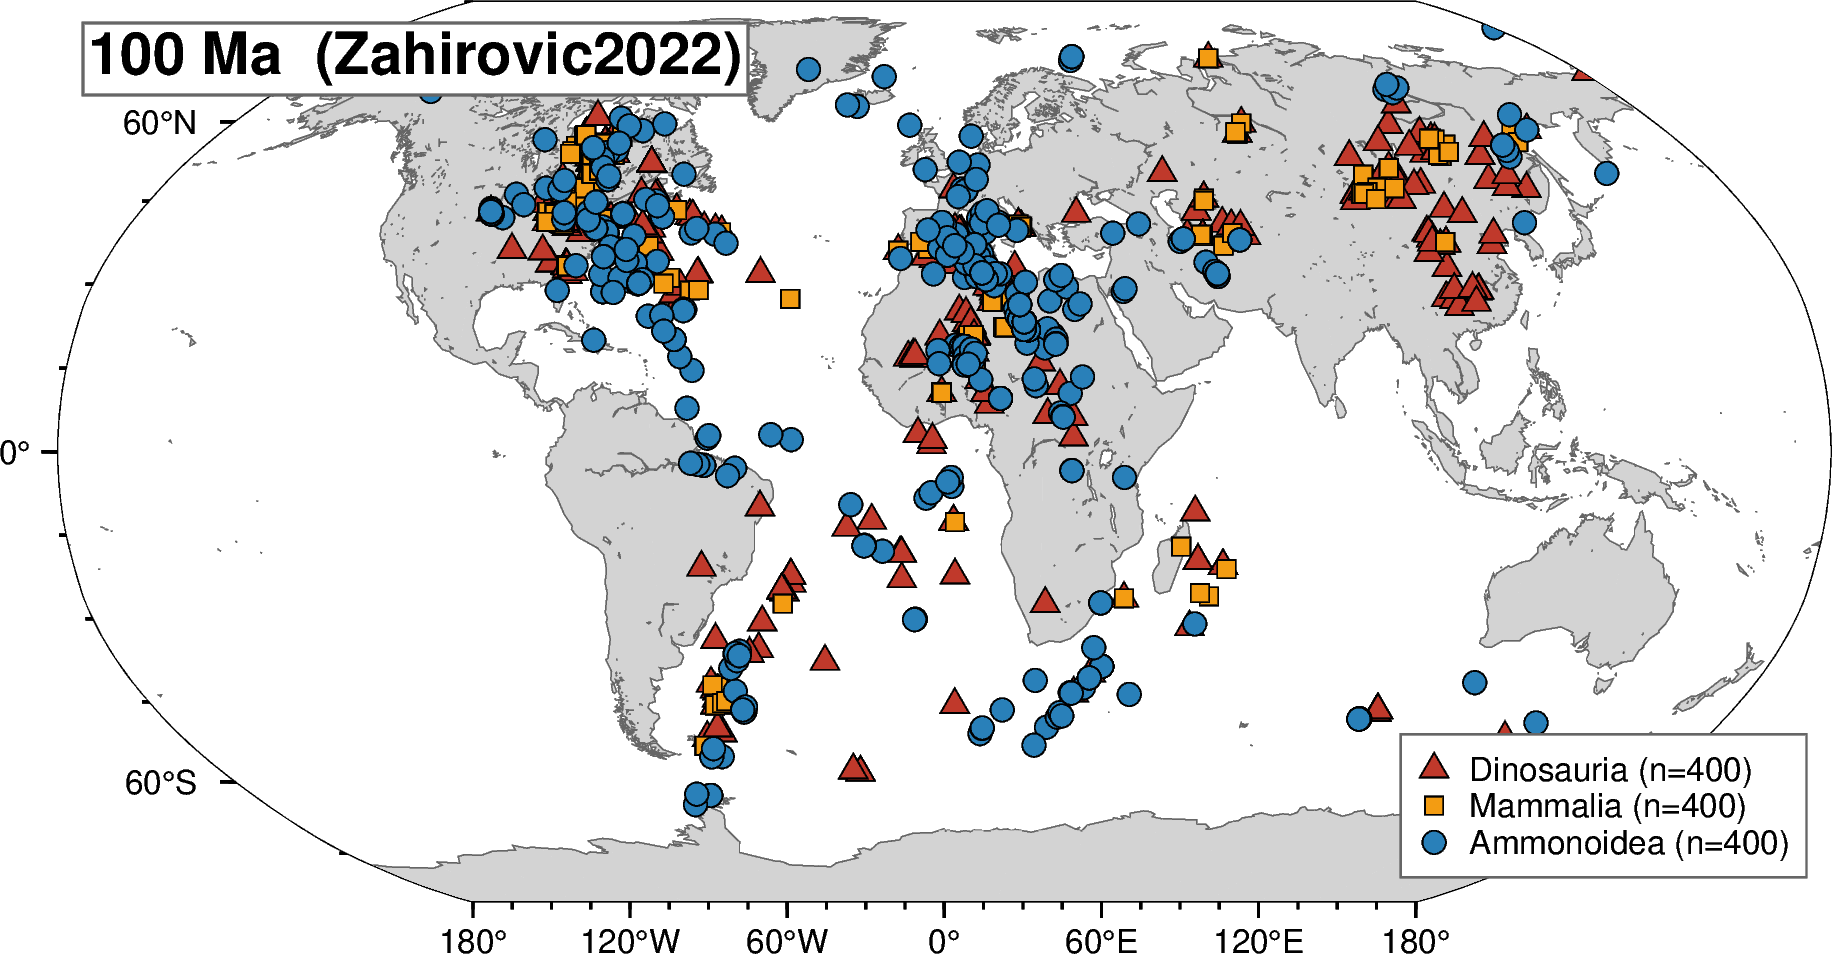

In [6]:
fig = pygmt.Figure()
REGION, PROJ = [-180, 180, -90, 90], "N15c"

gplot.time = RECONSTRUCTION_TIME
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(region=REGION, projection=PROJ, land="lightgray", water="white",
          shorelines="0.25p,gray40")

# Continuous topological backbone
try:
    engine = gplately.pygmt_plot.PygmtPlotEngine()
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen="0.5p,gray55")
    engine.plot_geo_data_frame(fig, gplot.get_continents(),
                               fill="gray95", pen="0.5p,gray45")
except Exception:
    pass

# Ridges + trenches styled
try:
    engine.plot_geo_data_frame(fig, gplot.get_ridges(), pen="0.7p,red")
    engine.plot_geo_data_frame(fig, gplot.get_trenches(), pen="0.7p,black")
except Exception:
    pass

# Plot occurrences by taxon
for taxon, df in recon_dfs.items():
    if len(df) == 0: continue
    style = PBDB_QUERIES[taxon]["style"]
    fig.plot(x=df["paleo_lon"], y=df["paleo_lat"],
             style=style["symbol"], fill=style["fill"], pen="0.3p,black",
             region=REGION, projection=PROJ,
             label=f"{taxon} (n={len(df)})")

fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.legend(position="JBR+jBR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)


### How to read the paleo-Earth map

- **Red triangles (Dinosauria)** — terrestrial. Cluster on Cretaceous paleo-continents. Look for latitudinal patterns (some Cretaceous polar dinosaurs?) and continental separation (post-Pangaean isolation of southern vs northern dinosaur faunas).
- **Orange squares (Mammalia)** — sparse in the Cretaceous; the classic Mesozoic mammal fossil record is heavily Laurasian. Absence of records from South American / African / Australian Cretaceous does NOT mean absence of mammals — it means preservational/sampling bias.
- **Blue circles (Ammonoidea)** — pelagic marine. Cluster along Tethyan and epicontinental sea margins. High cosmopolitanism (single genera occur globally) is a well-documented Cretaceous ammonoid pattern.

**Watch for sampling biases.** PBDB is a sampling of what has been described and entered — not a sampling of what actually existed. Rich Wyoming / Alberta / Mongolia dinosaur records will dominate the northern-hemisphere red-triangle count even when Gondwanan dinosaur diversity was comparable.


## 5. Latitudinal diversity gradient


In [7]:
fig = pygmt.Figure()
fig.basemap(region=[-90, 90, 0, 60], projection="X18c/7c",
            frame=["WSne+t" + f"Latitudinal diversity gradient at "
                   f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
                   "xa30f10+lPaleolatitude (°)",
                   f"yaf+lOccurrences per {LAT_BIN_DEG}° bin"])

# equator marker
fig.plot(x=[0, 0], y=[0, 60], pen="1p,black,-")
fig.text(x=0, y=55, text="equator", font="8p,Helvetica,black",
         justify="LB", offset="0.2c/0.1c", no_clip=True)

for taxon, df in recon_dfs.items():
    if len(df) == 0: continue
    style = PBDB_QUERIES[taxon]["style"]
    fig.histogram(data=df["paleo_lat"].dropna().values,
                  series=f"-90/90/{LAT_BIN_DEG}",
                  pen="0.4p,black", fill=f"{style['fill']}@40",
                  region=[-90, 90, 0, 60], projection="X18c/7c",
                  label=f"{taxon} (n={len(df)})")

fig.legend(position="JTR+jTR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)


### How to read the latitudinal-diversity gradient

- **Symmetric tropical peak?** The modern latitudinal diversity gradient (LDG) shows equatorial diversity ~5× higher than polar. Cretaceous LDG is thought to have been flatter — Mesozoic ammonoids in particular were nearly cosmopolitan.
- **Northern-hemisphere bias?** Almost all PBDB taxonomic groups over-sample the northern hemisphere by 2-3× because that's where most collecting has happened. This is sampling bias, not a real biogeographic signal.
- **A dinosaur record with no equatorial occurrences?** Not necessarily "no dinosaurs at the equator" — could just mean "no equatorial exposures with described dinosaurs in PBDB". Compare against the ammonoid and mammal records to see whether the gap is taxon-specific (biological) or common to all three (sampling).


## Extend this

- **Vary the interval.** Change `interval` in each query to `Jurassic`, `Triassic`, `Devonian`, or a specific stage (e.g. `Cenomanian`). Try the end-Permian: `interval: Permian` and `interval: Triassic` on the same map for a mass-extinction contrast.
- **Compare more taxa.** Swap in `Bivalvia`, `Brachiopoda`, `Foraminifera`, `Angiospermae`, `Coleoptera`. The PBDB taxonomy tree at <https://paleobiodb.org/classic/checkTaxonInfo> is browsable.
- **Diversity through time.** Loop `RECONSTRUCTION_TIME` from 250 to 0 Ma at 10-Myr cadence and render a video of one taxonomic group's paleo-distribution through the Meso-Cenozoic.
- **Constrain by lithology.** PBDB `show=lith` includes lithology descriptors. Filter to `carbonate` for Cretaceous ammonoids, or `terrestrial` for dinosaurs, to see how sedimentary-environment sampling biases the biogeographic reconstruction.
- **Ecological structure.** Group occurrences by ecomorphotype (marine benthic vs pelagic; terrestrial herbivore vs carnivore) using PBDB's `ecl` field.
- **Bias correction.** Alroy et al.'s shareholder-quorum subsampling can correct raw counts for uneven sampling — try implementing it on the latitude-binned counts.

## Related notebooks

- **T41** — reef builders paleolatitude (Boucot 1999 catalog, offline / pre-bundled — a *closed* version of what T64 does with a live PBDB query).
- **T44** — Boucot climate-sensitive lithologies (paleolithology, similar reconstruction pattern).
- **T62** — ophiolite emplacement paleo-map (a non-biological point-catalog on the same paleo-Earth infrastructure).

## Sources

- Peters, S.E. & McClennen, M. (2016). The Paleobiology Database application programming interface. *Paleobiology* 42(1), 1-7. doi:10.1017/pab.2015.39.
- PBDB API docs: <https://paleobiodb.org/data1.2/> (occurrence list endpoint at <https://paleobiodb.org/data1.2/occs/list_doc.html>).
- Alroy, J. (2010). Fair sampling of taxonomic richness and unbiased estimation of origination and extinction rates. In *Quantitative methods in paleobiology*, Paleontological Society Papers 16, 55-80.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. doi:10.1002/gdj3.146.
